In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
%%capture
import os, re, subprocess
if "KAGGLE_KERNEL_RUN_TYPE" not in os.environ:
    !pip install unsloth
else:
    import torch
    v = re.match(r'[\d]+\.[\d]+', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {
        '2.10': '0.0.34',
        '2.9': '0.0.33.post1',
        '2.8': '0.0.32.post2'
    }.get(v, "0.0.34")
    !pip install sentencepiece protobuf "datasets==4.3.0" \
        "huggingface_hub>=0.34.0" hf_transfer
    subprocess.run(
        f"pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth",
        shell=True
    )
!pip install transformers==5.3.0
!pip install --no-deps trl==0.22.2
!pip install --force-reinstall pyarrow  

# restart kernel after this and do not run this cell

In [1]:
from unsloth import FastVisionModel 
import torch

model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Qwen2-VL-2B-Instruct",  
    load_in_4bit = False,
    use_gradient_checkpointing = "unsloth",
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.3.8: Fast Qwen2_Vl patching. Transformers: 5.3.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.33.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


In [2]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = True, # False if not finetuning vision layers
    finetune_language_layers   = True, # False if not finetuning language layers
    finetune_attention_modules = True, # False if not finetuning attention layers
    finetune_mlp_modules       = True, # False if not finetuning MLP layers

    r = 16,           # The larger, the higher the accuracy, but might overfit
    lora_alpha = 16,  # Recommended alpha == r at least
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,  # We support rank stabilized LoRA
    loftq_config = None, # And LoftQ
    # target_modules = "all-linear", # Optional now! Can specify a list if needed
)

Unsloth: Making `model.base_model.model.model.visual` require gradients


In [4]:

from datasets import load_dataset
dataset = load_dataset("damerajee/hindi-ocr" , split = "train")

In [5]:
dataset


Dataset({
    features: ['image', 'text'],
    num_rows: 388
})

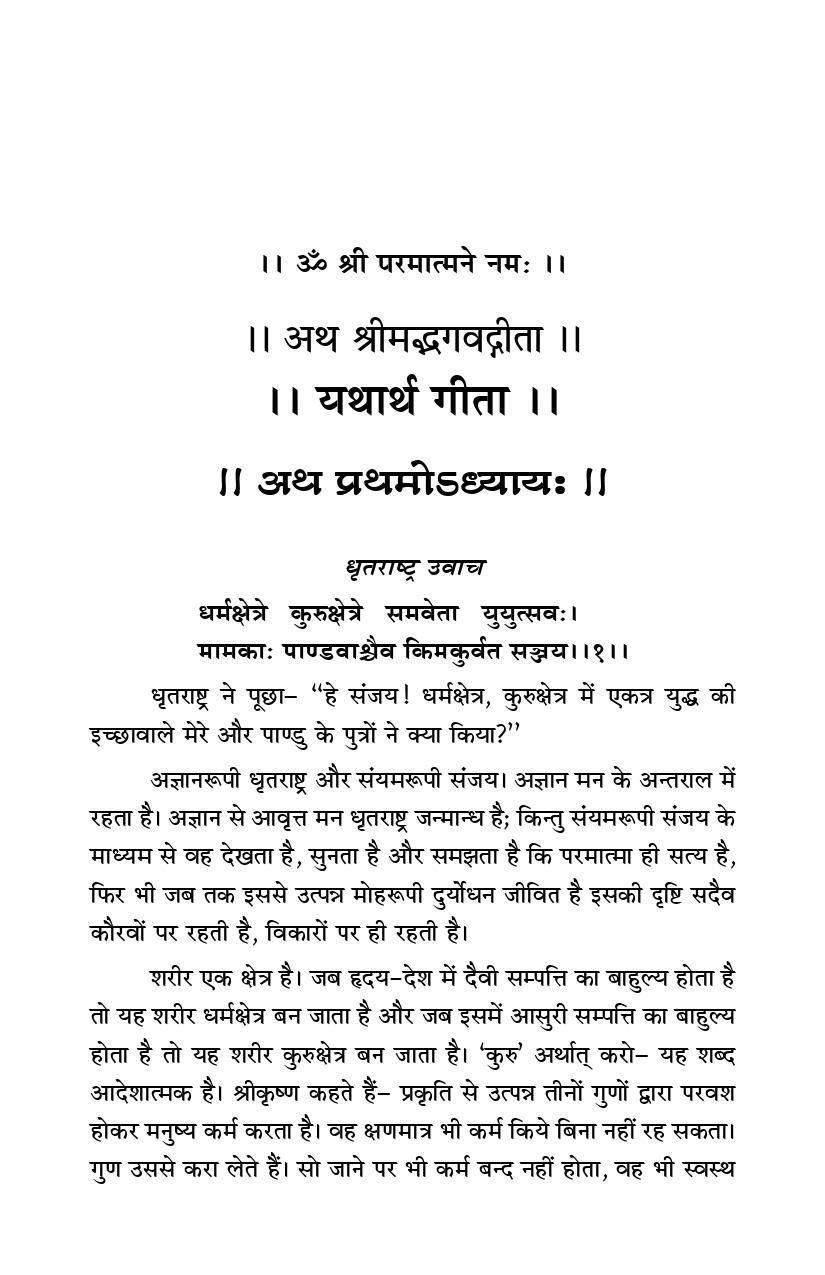

In [6]:
dataset[0]['image']

In [7]:
instruction = "Write the hindi representation for this image."

def convert_to_conversation(sample):
    conversation = [
        { "role": "user",
          "content" : [
            {"type" : "text",  "text"  : instruction},
            {"type" : "image", "image" : sample["image"]} ]
        },
        { "role" : "assistant",
          "content" : [
            {"type" : "text",  "text"  : sample["text"]} ]
        },
    ]
    return { "messages" : conversation }
pass

In [8]:
converted_dataset = [convert_to_conversation(sample) for sample in dataset]

In [12]:
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

FastVisionModel.for_training(model) 

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = UnslothVisionDataCollator(model, tokenizer), # Must use!
    train_dataset = converted_dataset,
    args = SFTConfig(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        max_steps = 40,
        # num_train_epochs = 1
        learning_rate = 3e-4,
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.001,
        lr_scheduler_type = "linear",  # can be set to cosine too
        seed = 3407,
        output_dir = "outputs",
        report_to = "none",     # For Weights and Biases
        

        # You MUST put the below items for vision finetuning:
        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
        max_length = 2048,
    ),
)

Unsloth: Model does not have a default image size - using 512


In [10]:
trainer_stats = trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 151645, 'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 388 | Num Epochs = 1 | Total steps = 40
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 28,950,528 of 2,237,936,128 (1.29% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
1,0.778052
2,0.761883
3,0.626328
4,0.487767
5,0.422217
6,0.412364
7,0.371781
8,0.342354
9,0.327127
10,0.293266


In [13]:
dataset

Dataset({
    features: ['image', 'text'],
    num_rows: 388
})

In [15]:
FastVisionModel.for_inference(model) 

image = dataset[0]["image"]
instruction = "Write the Hindi representation for this image."

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": instruction}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 628,
                   use_cache = True, temperature = 1.5, min_p = 0.1)

Both `max_new_tokens` (=628) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


१| अँ श्री परमात्मने नमः १| अथ श्रीमद्भगवद्गीता १| यथार्थ गीता १| अथ प्रथमौर्क्ष्यायः १| धृतराष्ट्र उवाच धर्मक्षेत्रे कुरुक्षेत्रे समवेता युयुत्सवः मामकाः पाण्डवाश्चेव किमकुर्वत सञ्चय१११| धृतराष्ट्र ने पूछा- उन्न्यां धर्मक्षेत्र, कुरुक्षेत्र में एकत्र युद्ध की इच्छावाले मेरे और पाण्डु के पुत्रों ने क्या किया? अज्ञानरूपी धृतराष्ट्र और संयमरूपी संजय| अज्ञान मन के अन्तराल में रहता है| अज्ञान से आवृत्त मन धृतराष्ट्र जन्मान्थ है; किन्तु संयमरूपी संजय के माध्यम से वह देखता है, सुनता है और समझता है कि परमात्मा ही सत्य है, फिर भी जब तक इससे उत्पन्न मोहरूपी दुर्योधन जीवित है इसकी दृष्टि सदैव कौरवों पर रहती है, विकारों पर ही रहती है| शरीर एक क्षेत्र है| जब हृदय
